# **Week 7 Applied Session: Data Auditing**


<div style=" color:black; text-shadow: 1px 1px brown; font-size:2em;">
    <h1 align="center">Scientific Python
    </div>


## Recall: Data cleansing process:

Data cleansing is an iterative process. The first step of the cleansing process is data auditing. In this step, we identify the types of anomalies that reduce the data quality.  Data auditing is about programmatically checking the data using some validation rules that are pre-specified, and then creating a report of the quality of the data and its problems. We often apply some statistical tests in this step for examining the data.
Data Anomalies can be classified at a high level into three categories:

1. **Syntactic Anomalies**:
describe characteristics concerning the format and values used for representation of the entities. Syntactic anomalies such as: lexical errors, domain format errors, syntactical error and irregularities.
2. **Semantic Anomalies**:
hinder the data collection from being a comprehensive and non-redundant representation of the mini-world. These types of anomalies include: Integrity constraint violations, contradictions, duplicates and invalid tuples
3. **Coverage Anomalies**:
decrease the amount of entities and entity properties from the mini-world that are represented in the data collection. Coverage anomalies are categorized as: missing values and missing tuples

We give examples in this part of the auditing process that is applied to discover different anomalies in data.
***



## **1. Wrangling Titanic Data**

The Titanic data is the data set provided in the Kaggle competition "Titanic: Machine Learning from Disaster". The competition has been available from 28 Sep 2012 with more than 4000 teams joining the competition.

"The sinking of the RMS Titanic is one of the most infamous shipwrecks in history.  On April 15, 1912, during her maiden voyage, the Titanic sank after colliding with an iceberg, killing 1502 out of 2224 passengers and crew. This sensational tragedy shocked the international community and led to better safety regulations for ships. One of the reasons that the shipwreck led to such loss of life was that there were not enough lifeboats for the passengers and crew. Although there was some element of luck involved in surviving the sinking, some groups of people were more likely to survive than others, such as women, children, and the upper-class. In this challenge, we ask you to complete the analysis of what sorts of people were likely to survive. In particular, we ask you to apply the tools of machine learning to predict which passengers survived the tragedy". For more details, please refer to "https://www.kaggle.com/c/titanic/overview"

The focus here is not the analysis of the data. Instead, we will concentrate on the identification of errors in the data, which might cause problems in the analysis. This data set contains the following variables
* <font color="blue">survival</font>: a boolean variable indicates whether the passenger survived or not.
* <font color="blue">pclass</font>: Passenger's Carbin Class
* <font color="blue">sex</font>: the gender of a passenger
* <font color="blue">age</font>: Age
* <font color="blue">sibsp</font>: Number of Siblings/Spouses Aboard
* <font color="blue">parch</font>: Number of Parents/Children Aboard
* <font color="blue">fare</font>: Passenger ticket Fare
* <font color="blue">embarked</font>: abbreviation of Port of Embarkation
* <font color="blue">class</font>: the passenger's carbin class
* <font color="blue">who</font>: a variable takes values in {man, woman, child}
* <font color="blue">adult_male</font>: a boolean variable
* <font color="blue">deck</font>: the deck
* <font color="blue">embark_town</font>: the name of the port of embarkation
* <font color="blue">alive</font>: whether or not the passenger was alive
* <font color="blue">alone</font>: a boolean variable indicates if the passenger traveled alone.
* <font color="blue">name</font>: Name of the passenger

For convenience, we will use the demo version of Titanic data included in the seaborne library: https://github.com/mwaskom/seaborn-data/blob/master/titanic.csv. For the purpose of demonstration,
some errors have been introduced in the data.
Notice that this task was developed based on the materials provided in the Kaggle website.

In [48]:
# from google.colab import drive
# drive.mount('/content/drive')

In [49]:
#Basic scientific python libs
import pandas as pd
# Visualisation
import matplotlib as mpl
import matplotlib.pyplot as plt
# Configure visualisations
%matplotlib inline
mpl.style.use( 'ggplot' )
#Notebook displace setting
from IPython.core.display import HTML
css = open('style/style-table.css').read() + open('style/style-notebook.css').read()
# css = open('/content/drive/Shareddrives/FIT5196_S2_2025/week7/style/style-table.css').read() + open('/content/drive/Shareddrives/FIT5196_S2_2025/week7/style/style-notebook.css').read()

HTML('<style>{}</style>'.format(css))

### 1.1 First, load the data using Pandas library

As we discussed in the lecture, the first thing you should do is to inpect the file and figure out the file format. It is not hard to see that the titanic data is store in a csv file. So we can use the <a href="http://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html">read_csv()</a> function.

Write you code below to load the csv file.

In [50]:
titanic = pd.read_csv('titanic_new.csv')

Now, the data has been loaded and stored in a Panda DataFrame. We can take an overview of the data. For example, you might need to know
* the number of columns, i.e., attributes, and what are the attributes?
* the number of rows, i.e., passengers
* what is the data type of each attributes?
and etc.

We start by looking at the dimensionality of the data and a few lines of the data.

In [51]:
print(titanic.shape)
titanic.tail(10)

(892, 16)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,name
882,0,3,female,22.0,0,0,10.5167,S,Third,woman,False,NaN,Southampton,no,True,"Dahlberg, Miss. Gerda Ulrika"
883,0,2,M,28.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True,"Banfield, Mr. Frederick James"
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True,"Sutehall, Mr. Henry Jr"
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False,"Rice, Mrs. William (Margaret Norton)"
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,"Montvila, Rev. Juozas"
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,"Graham, Miss. Margaret Edith"
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,"Johnston, Miss. Catherine Helen ""Carrie"""
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,"Behr, Mr. Karl Howell"
890,0,3,M,32.0,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True,"Dooley, Mr. Patrick"
891,1,1,male,26.0,0,0,30.0000,Q,First,man,True,C,Cherbourg,no,False,"Behr, Mr. Karl Howell"


You can also print out the last couple of rows with the <font color="orange">tail()</font> function. We've got a sense of the variables, their class type, and the first few observations of each by observing the data. We know we're working with 892 observations of 15 variables.

Next, we have a look at some key information about each variable to answer the following questions
* **Which features are categorical?** These values classify the samples into sets of similar samples. Within categorical features are the values nominal, ordinal, ratio, or interval based?
    * Categorical variables:<font color="blue">survived</font>, <font color="blue">sex</font>, <font color="blue">embarked</font>, <font color="blue">who</font>, <font color="blue">embark_town</font>, <font color="blue">alive</font>, <font color="blue">alone</font>, and <font color="blue">name</font>, <font color="blue">deck</font>
    * Ordinal variables: <font color="blue">pclass</font>, <font color="blue">class</font>,
* **Which features are numerical**? Which features are numerical? Within numerical features are the values discrete, continuous, or time-series based?
    * Continuous: <font color="blue">age</font>, <font color="blue">fare</font>.
    * Discrete: <font color="blue">sibsp</font>, <font color="blue">parch</font>.

Answering these questions will help us select the appropriate methods(e.g., plots) to audit the data.

In [52]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     892 non-null    int64  
 1   pclass       892 non-null    int64  
 2   sex          892 non-null    object 
 3   age          715 non-null    float64
 4   sibsp        892 non-null    int64  
 5   parch        892 non-null    int64  
 6   fare         892 non-null    float64
 7   embarked     890 non-null    object 
 8   class        892 non-null    object 
 9   who          892 non-null    object 
 10  adult_male   892 non-null    bool   
 11  deck         204 non-null    object 
 12  embark_town  890 non-null    object 
 13  alive        892 non-null    object 
 14  alone        892 non-null    bool   
 15  name         892 non-null    object 
dtypes: bool(2), float64(2), int64(4), object(8)
memory usage: 99.4+ KB


What is the distribution of the numerical values across the samples? This helps us determine, among other early insights, how representative is the training dataset of the actual problem domain.

Use the <font color="orange">describe()</font> function to get the distribution of each variable.

In [53]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,892.000000,892.000000,715.000000,892.000000,892.000000,892.000000
mean,0.384529,2.307175,29.720517,0.522422,0.381166,32.201737
std,0.486757,0.836750,14.490914,1.102264,0.805706,49.665589
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.750000,0.000000,0.000000,7.917700
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [54]:
titanic.describe(include=['object'])

,sex,embarked,class,who,deck,embark_town,alive,name
count,892,890,892,892,204,890,892,892
unique,4,3,3,3,7,7,2,891
top,male,S,Third,man,C,Southampton,no,"Behr, Mr. Karl Howell"
freq,574,644,491,538,60,643,550,2


The observation tells us that
* Total samples are 892 or 40% of the actual number of passengers on board the Titanic (2,224).
* Survived is a categorical feature with 0 or 1 values.
* Most passengers (> 75%) did not travel with parents or children.
* Nearly 30% of the passengers had siblings and/or spouse aboard.
* Fares varied significantly with few passengers paying as high as $512, and as low as 0.0.
* Few elderly passengers within age range 65-80.
* The minimum age is 0.42.
* Some missing values exist in the "age","deck" column

Again, what is the distribution of the categorical variables?

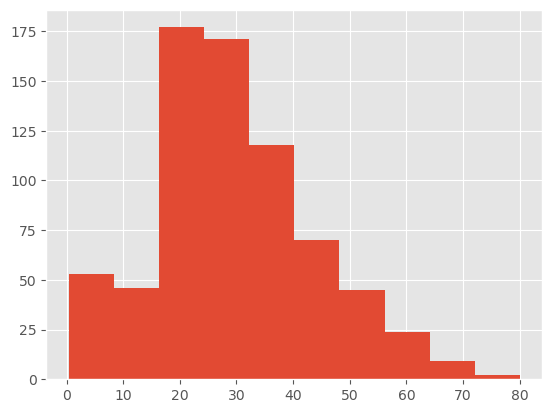

np.int64(177)

In [55]:
# hist for age
titanic.age.hist()
plt.show()
# show null values for this column
titanic.age.isnull().sum()

What the table above tells us:
* Names are not unique across the dataset (count !=unique), "Behr, Mr. Karl Howell" appears twice.
* Sex variable as four possible values with 574 males, which is suspicious.
* Embarked takes three possible values. In contrast, the embark_town takes 7 different values. However, if the two values represent the same information, it becomes suspicious.
* Alive is a boolean variable
* There are a lot of missing values in deck, and 2 in both <font color="blue">embarked</font> and <font color="blue">embark_town</font>.

It is clear that the summary statistics on the distributions of each variable gives us a lot of information about the variable. Before we continue our auditing process, we are could further split the "name" column into more meaningful columns for better analysis.

In [56]:
titanic['name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
891                                Behr, Mr. Karl Howell
Name: name, Length: 892, dtype: object

In [57]:
coltitle = titanic['name'].apply(lambda s: pd.Series({'title': s.split(',')[1].split('.')[0].strip(),
                            'lastName':s.split(',')[0].strip(), 'firstName':s.split(',')[1].split('.')[1].strip()}))
coltitle

titanic = pd.concat([titanic, coltitle], axis=1)

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,name,title,lastName,firstName
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,"Braund, Mr. Owen Harris",Mr,Braund,Owen Harris
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,Cumings,John Bradley (Florence Briggs Thayer)
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,"Heikkinen, Miss. Laina",Miss,Heikkinen,Laina
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,Futrelle,Jacques Heath (Lily May Peel)
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,"Allen, Mr. William Henry",Mr,Allen,William Henry


Notice that we kept the "name" column for now, as we might need to check where we have correctly split it into three columns.

### **Task 1: Identify Syntactical Anomalies**
In this section, we will demonstrate how to audit the data to identify some syntactical errors.




#### **Task 1.1: Are all the titles consistent?**

Let's start with checking the <font color="blue">title</font> column, as we just extract it from the <font color="blue">name</font> column. We used the <font color="orange">split()</font> function together with the following delimiters: "," and "." Is it possible that the split method we used gave us some erroneous extraction?

Write you code to count the frequency of each unique value of title. (Hint: use the <font color="orange">value_counts()</font> function.

In [58]:
titanic.title.value_counts()

title
Mr              518
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

We have got 17 different titles. We might ask if it is possible to have 17 different titles, as those often used are Mr, Mrs, Miss, Ms, and Dr. What is the meaning of the following title?
* Rev
* Mlle
* Jonkheer
* Don
* Mme
* The countess

Is it possible that the patten we used to extract Title is not applicable to all the records?

In this case, we might need to have a look at the rows whose title is equal to the tiles listed above. For example, we look at "Rev".

Write your code below to print those rows:

In [59]:
titanic.title.replace(
    {'Mlle': 'Miss',
    'Mme': 'Miss',
    'Lady': 'Miss',
    'Countess': 'Miss',
    'Ms': 'Miss',
    'Don': 'Mr',
    'Mme': 'Miss',
    'Rev': 'Mr',
    'Dr': 'Mr',
    'Major': 'Mr',
    'Col': 'Mr',
    'Capt': 'Mr',
    'Jonkheer': 'Mr',
    'The countess': 'Miss',
    'the Countess': 'Miss',
    'The Countess': 'Miss',
    'Sir': 'Mr',
    }, inplace=True
)

/var/folders/jb/gyj0mskn1d5bh5qgnqp4zn0w0000gn/T/ipykernel_9724/1103948284.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic.title.replace(


In [60]:
titanic.title.value_counts()

title
Mr        539
Miss      188
Mrs       125
Master     40
Name: count, dtype: int64

The are six rows in the DataFrame that contain "Rev". It seams that "Rev" is not a random lexical error, instead it might be a valid title that is not use often nowadays. We can check if "Rev" is a title by searching it online. What we will get from Wikipedia is
> The Reverend is an honorific style most often placed before the names of Christian clergy and ministers. There are sometimes differences in the way the style is used in different countries and church traditions

We can confirm that Rev is a title that is not often used nowadays. Similarly, you can check the other titles as well. It is interesting that "The countess" and "Mlle" are titles for female and "Don" for male. Should we unify these titles? For instance, assume that we are going to unify the title values by replacing "The countess", "Lady", "Mme" and "Mlle" with "Miss" and "Don" with "Mr", what should we do?

Write your code to replace
* "Mlle", "the Countess", "Lady" and "Mme" with "Miss";
* "Don" with "Mr".

Now, we can drop the <font color="blue">name</font> column.

In [61]:
titanic.drop(columns=['name'], inplace=True)
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,title,lastName,firstName
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,Mr,Braund,Owen Harris
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Mrs,Cumings,John Bradley (Florence Briggs Thayer)
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Miss,Heikkinen,Laina
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Mrs,Futrelle,Jacques Heath (Lily May Peel)
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,Mr,Allen,William Henry


#### **Task 1.2: Are there any lexical errors in the data?**
Typos are the most common error, particularly whenever the data collection process involves human. While we were collecting the data, we might mis-type the name of the embark_town. It is always a good idea to check the categorical variables to make sure their values are spelled without errors. Let's look at the <font color="blue">embark_town</font>. You can also use the <font color="orange">value_counts()</font> function or the <font color="orange">unique()</font> function.

In [62]:
titanic.embark_town.value_counts()

embark_town
Southampton    643
Cherbourg      167
Queenstown      75
queenstown       2
Southamtpon      1
Cherbourge       1
Cherborg         1
Name: count, dtype: int64

The output above show that
* typos
    * Cherbourg v.s. Cherborg
    * Southampton v.s. Southamtpon
    * Cherbourg v.s. Cherbourge
* Inconsistent spelling:
 * Queenstown v.s. queenstown

The assumption we made here is that it is less likely that the spelling with large counts is wrong. You can also check  <font color="blue">embark_town</font> against <font color="blue">embarked</font>.

Now, replace the typos with the crossponding right spelling.

In [63]:
titanic.replace({'embark_town': 
{"Cherborg": "Cherbourg", "Cherbourge": "Cherbourg", "Southamtpon":"Southampton", "queenstown":"Queenstown"}
}, inplace=True)
titanic.embark_town.value_counts()

embark_town
Southampton    644
Cherbourg      169
Queenstown      77
Name: count, dtype: int64

The cross-tabulation of <font color="blue">embark_town</font> and <font color="blue">embarked</font> below proves the correspondence between the values of <font color="blue">embark_town</font> and those of <font color="blue">embarked</font>.

Write you code to generate the cross-tabulation; (Hint: use the <font color="orange">crosstab()</font> function)

In [64]:
pd.crosstab(titanic.embark_town, titanic.embarked)

embarked,C,Q,S
embark_town,,,
Cherbourg,168,1,0
Queenstown,0,77,0
Southampton,0,0,644


In [65]:
titanic[(titanic.embark_town=="Cherbourg") & (titanic.embarked=="Q")]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,title,lastName,firstName
891,1,1,male,26.0,0,0,30.0,Q,First,man,True,C,Cherbourg,no,False,Mr,Behr,Karl Howell


#### **Task 1.3: Further more, are their any other inconsistent spellings?**
Here, we are going to use the <font color="blue">sex</font> variable as an example. The observation told us that it is a boolean variable that takes two values, i.e., <font color="blue">male</font> and <font color="blue">female</font> with lower case letters. Let's check is unique values in the <font color="blue">sex</font> column.

In [66]:
titanic.sex.unique()

array(['male', 'female', 'M', 'F'], dtype=object)

The output shows the number of unique values in "sex" is 4, which is supposed to be 2. The inconsistency here is obvious. We can either replace male/female with M/F or M/F with male/female.

Write your code to replace "M" with "male" and "F" with "female".

In [67]:
titanic.replace({'sex': 
{"M": "male", "F": "female"}
}, inplace=True)
titanic.sex.unique()

array(['male', 'female'], dtype=object)

You can check all the other categorical variables in a similar way.


### **Task 2: Identify Semantic Anomalies:**
Variables can be correlated with each other. One variable might provide information that we can use to validate another variable.  In this task, we will check where nor not the data
* violate the integrity constraints
* contradictions
* duplication



#### **Task 2.1: Check Integrity Constraints**
We firstly check the integrity constraints. Given the variable description, one can figure out that "age", "who"
and "adult_male" are correlated. For example, **if we assume all the children should under 18, and both men and women should be 18 or above**,
* Were all children's ages under 18?
* Were the ages of all men and women greater than or equal to 18?

To answer the questions, we need to compute the summary statistics individually for passengers marked as child, man and woman.

One way is to use the <font color="orange">describe()</font> function together with the <font color="orange">groupby()</font> function.

In [68]:
titanic['age'].groupby(titanic['who']).describe()

,count,mean,std,min,25%,50%,75%,max
who,,,,,,,,
child,83.0,6.598434,5.151912,0.42,2.0,5.0,10.0,25.0
man,414.0,33.155797,12.896093,16.00,23.0,30.0,40.0,80.0
woman,218.0,32.000000,11.495441,16.00,23.0,30.0,39.0,63.0


The statistics shows that there are 83 children, 413 men and 218 women.

Write your code to show the passagers satisifing the following conditions:
* titanic.who = man or woman
* titanic.age < 18

In [69]:
titanic[((titanic.who == "man") | (titanic.who == "woman")) & (titanic.age < 18)]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,title,lastName,firstName
68,1,3,female,17.0,4,2,7.9250,S,Third,woman,False,NaN,Southampton,yes,False,Miss,Andersson,Erna Alexandra
71,0,3,female,16.0,5,2,46.9000,S,Third,woman,False,NaN,Southampton,no,False,Miss,Goodwin,Lillian Amy
84,1,2,female,17.0,0,0,10.5000,S,Second,woman,False,NaN,Southampton,yes,True,Miss,Ilett,Bertha
86,0,3,male,16.0,1,3,34.3750,S,Third,man,True,NaN,Southampton,no,False,Mr,Ford,William Neal
114,0,3,female,17.0,0,0,14.4583,C,Third,woman,False,NaN,Cherbourg,no,True,Miss,Attalah,Malake
138,0,3,male,16.0,0,0,9.2167,S,Third,man,True,NaN,Southampton,no,True,Mr,Osen,Olaf Elon
156,1,3,female,16.0,0,0,7.7333,Q,Third,woman,False,NaN,Queenstown,yes,True,Miss,Gilnagh,"Katherine ""Katie"""
163,0,3,male,17.0,0,0,8.6625,S,Third,man,True,NaN,Southampton,no,True,Mr,Calic,Jovo
208,1,3,female,16.0,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True,Miss,Carr,"Helen ""Ellen"""
220,1,3,male,16.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,yes,True,Mr,Sunderland,Victor Francis


There are 30 passenger should be classified as man and woman respectively. Now we can replace the value of <font color="blue">who</font> for the above record to "child", given the assumption we made.

Change the value of <font color="blue">who</font> to "child" for the rows you found above.

In [70]:
titanic.loc[((titanic.who == "man") | (titanic.who == "woman")) & (titanic.age < 18), "who"] = "child"


Instead of using the <font color="orange">describe()</font> function, you can also choose to use plot. For example,

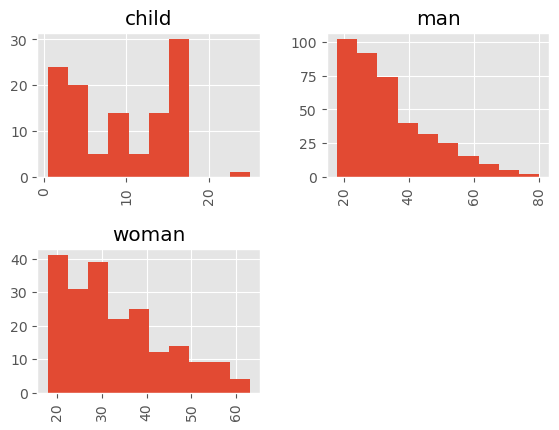

In [71]:
titanic.hist(by="who", column="age")
plt.show()

In [72]:
titanic[(titanic.age == 25) & (titanic.who=='child')]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,title,lastName,firstName
813,0,3,female,25.0,4,2,31.275,S,Third,child,False,NaN,Southampton,no,False,Miss,Andersson,Ebba Iris Alfrida


In [73]:
titanic.loc[(titanic.age == 25) & (titanic.who=='child'), 'who'] = "woman"
titanic.loc[813,]

survived                       0
pclass                         3
sex                       female
age                         25.0
sibsp                          4
parch                          2
fare                      31.275
embarked                       S
class                      Third
who                        woman
adult_male                 False
deck                         NaN
embark_town          Southampton
alive                         no
alone                      False
title                       Miss
lastName               Andersson
firstName      Ebba Iris Alfrida
Name: 813, dtype: object

In [74]:
pd.crosstab(titanic.sex, titanic.who)

who,child,man,woman
sex,,,
female,54,0,260
male,58,520,0


The tabulation shows that all the women have gender "female" and all the men have gender "male".
#### **Task 2.2: Check Contradictions**

Are the values of "adult_male" consistent with the values of "sex" and "who"?

Now, let's look at <font color="blue">adult_male</font>, the value of which should "True" if a passenger is male and adult, "False" if a passenger is female or a male child. In other words, we need to check the consistency among three variables. What should we do?

In [75]:
titanic[(titanic.adult_male) & ((titanic.sex != "male") | (titanic.who != "man"))]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,title,lastName,firstName
86,0,3,male,16.0,1,3,34.3750,S,Third,child,True,NaN,Southampton,no,False,Mr,Ford,William Neal
138,0,3,male,16.0,0,0,9.2167,S,Third,child,True,NaN,Southampton,no,True,Mr,Osen,Olaf Elon
163,0,3,male,17.0,0,0,8.6625,S,Third,child,True,NaN,Southampton,no,True,Mr,Calic,Jovo
220,1,3,male,16.0,0,0,8.0500,S,Third,child,True,NaN,Southampton,yes,True,Mr,Sunderland,Victor Francis
266,0,3,male,16.0,4,1,39.6875,S,Third,child,True,NaN,Southampton,no,False,Mr,Panula,Ernesti Arvid
282,0,3,male,16.0,0,0,9.5000,S,Third,child,True,NaN,Southampton,no,True,Mr,de Pelsmaeker,Alfons
333,0,3,male,16.0,2,0,18.0000,S,Third,child,True,NaN,Southampton,no,False,Mr,Vander Planke,Leo Edmondus
433,0,3,male,17.0,0,0,7.1250,S,Third,child,True,NaN,Southampton,no,True,Mr,Kallio,Nikolai Erland
500,0,3,male,17.0,0,0,8.6625,S,Third,child,True,NaN,Southampton,no,True,Mr,Calic,Petar
532,0,3,male,17.0,1,1,7.2292,C,Third,child,True,NaN,Cherbourg,no,False,Mr,Elias,Joseph Jr


In [76]:
titanic[(titanic.adult_male == False) & ((titanic.sex == "male") & (titanic.age > 18))]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,title,lastName,firstName


In [77]:
titanic.loc[(titanic.adult_male) & ((titanic.sex != "male") | (titanic.who != "man")), "adult_male"]=False
titanic[(titanic.age < 10) & (titanic.alone)]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,title,lastName,firstName
777,1,3,female,5.0,0,0,12.475,S,Third,child,False,NaN,Southampton,yes,True,Miss,Emanuel,Virginia Ethel


The output shows that there was a 5-years old girl who was on-board and survived. Should we change the value of <font color="blue">alone</font>? The value is consistent with the value of <font color="blue">silbsp</font> and that of <font color="blue">parch</font>. In this case, we might choose to keep it as it is.

#### **Task 2.3: Check Duplicates**
Are there any duplicated records?

If we assume that <font color="blue">firstName</font>, <font color="blue">lastName</font> and <font color="blue">age</font> can uniquely identify a passenger, we can then use the three values to check whether or not the dataset contains duplicated records.

Write you code to find the duplicates:

In [80]:
titanic[titanic.duplicated(["firstName", "lastName", "age"], keep=False)]



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,title,lastName,firstName
889,1,1,male,26.0,0,0,30.0,C,First,man,True,C,Cherbourg,yes,True,Mr,Behr,Karl Howell
891,1,1,male,26.0,0,0,30.0,Q,First,man,True,C,Cherbourg,no,False,Mr,Behr,Karl Howell


In [81]:
titanic[titanic.duplicated(["firstName", "lastName", "age"], keep="first")]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,title,lastName,firstName
891,1,1,male,26.0,0,0,30.0,Q,First,man,True,C,Cherbourg,no,False,Mr,Behr,Karl Howell


In [82]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,title,lastName,firstName
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,Mr,Braund,Owen Harris
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Mrs,Cumings,John Bradley (Florence Briggs Thayer)
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Miss,Heikkinen,Laina
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Mrs,Futrelle,Jacques Heath (Lily May Peel)
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,Mr,Allen,William Henry
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,Miss,Graham,Margaret Edith
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,Miss,Johnston,"Catherine Helen ""Carrie"""
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,Mr,Behr,Karl Howell
890,0,3,male,32.0,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True,Mr,Dooley,Patrick


好，我来给你总结一下这个 Notebook 的完整流程、关键步骤、实用小技巧（tips），以及涉及到的 **pandas 语法**。这样你之后回顾或应用到别的项目时会很快上手。



------





# **📘 Notebook 总结：数据清洗流程 (Titanic 数据)**







## **Step 0. 数据审计目标**





- **发现并修复数据问题**：包括拼写错误、逻辑矛盾、重复记录。

- **数据质量检查三类问题**：

  

  1. **Syntactic**（词法/格式）：拼写错误、大小写不一致、非法值。
  2. **Semantic**（语义）：变量间矛盾（如 age<18 但标记为 man）。
  3. **Coverage**（覆盖）：缺失值、丢失信息。

  





------





## **Step 1. 检查拼写错误 (Lexical Errors)**





- 工具函数：



```
titanic["embark_town"].value_counts()
titanic["embark_town"].unique()
```



- 
- 修复拼写：



```
titanic.replace({
    "embark_town": {
        "Cherborg": "Cherbourg", 
        "Cherbourge": "Cherbourg",
        "Southampon": "Southampton",
        "queenstown": "Queenstown"
    }
}, inplace=True)
```



- 
- 冗余字段交叉验证：



```
pd.crosstab(titanic["embark_town"], titanic["embarked"])
```





**Tip**: 高频值通常是正确的，低频值要重点排查。



------





## **Step 2. 检查语义异常 (Semantic Anomalies)**







### **2.1 完整性约束 (Integrity Constraints)**





- 统计：



```
titanic["age"].groupby(titanic["who"]).describe()
```



- 
- 规则检查：



```
# child 应 age<18
(titanic["who"]=="child") & (titanic["age"]>=18)

# man/woman 应 age≥18
(titanic["who"].isin(["man","woman"])) & (titanic["age"]<18)
```







### **2.2 矛盾 (Contradictions)**





- **who 与 sex**：



```
pd.crosstab(titanic["who"], titanic["sex"])
```



- 
- **adult_male 与 sex+age**：



```
expected_adult_male = (titanic["sex"]=="male") & (titanic["age"]>=18)
titanic["adult_male"] != expected_adult_male
```



- 
- **alone 与 sibsp+parch**：



```
(titanic["sibsp"]+titanic["parch"]==0) & (titanic["alone"]==False)
```



- 
- **alive 与 survived**：



```
titanic["alive"].map({"yes":1,"no":0}) != titanic["survived"]
```





**Tip**: 建议不要直接覆盖原始列，而是生成 *_fixed 列，方便回溯。



------





## **Step 3. 检查重复 (Duplicates)**





- 查找重复：



```
titanic[titanic.duplicated(["firstName","lastName","age"], keep=False)]
```



- 
- 保留第一条，删掉其余：



```
titanic.drop_duplicates(["firstName","lastName","age"], keep="first", inplace=True)
```





**Tip**: 完全重复可直接删；部分重复且冲突时要人工判断或用“字段更完整”优先策略。



------





## **Step 4. 结果验证**





- 直方图（检查 age 分布是否合理）：



```
titanic.hist(by="who", column="age")
```



- 
- 冗余字段一致性：



```
pd.crosstab(titanic["embark_town"], titanic["embarked"])
```





------





# **🛠️ Pandas 语法回顾**



| **功能**   | **Pandas 语法**                                              |
| ---------- | ------------------------------------------------------------ |
| 查看唯一值 | df["col"].unique()                                           |
| 统计频数   | df["col"].value_counts(dropna=False)                         |
| 缺失比例   | df.isna().mean()                                             |
| 替换取值   | df.replace({"col":{"错值":"对值"}}, inplace=True)            |
| 交叉表     | pd.crosstab(df["col1"], df["col2"])                          |
| 分组统计   | df.groupby("col")["num"].describe()                          |
| 布尔筛选   | df[(条件1) & (条件2)]                                        |
| 标记重复   | df.duplicated(subset=["col1","col2"], keep=False)            |
| 删除重复   | df.drop_duplicates(subset=[ [Week_7_applied_session copy.ipynb](/Volumes/Mac Mini SSD external/DataScience/FIT5196/2025/wekk7/Week_7_applied_session copy.ipynb) "col1","col2"], keep="first") |
| 条件赋值   | df.loc[条件, "col"] = 新值                                   |



------





# **✨ 总结 Tips**





1. **先审计再修复**：先用 value_counts、crosstab、groupby 找问题，再决定如何修。
2. **多用冗余验证**：利用不同字段间的对应关系（如 who vs age+sex，alive vs survived）。
3. **保留追溯性**：新增 *_fixed 列，不要覆盖原始列。
4. **处理重复时要小心**：完全重复直接删，冲突重复要人工或规则决策。
5. **代码简洁**：多用布尔掩码 df[mask] 和 df.loc[mask, col] = val，是 pandas 清洗的核心套路。



